# Comparando Regressão Logística e Árvore de Decisão

## `Titanic Dataset`

Neste notebook, comparamos dois modelos de classificação:
- **Regressão Logística**
- **Árvore de Decisão**

O objetivo é prever a sobrevivência de passageiros do Titanic com base em variáveis como sexo, idade, classe etc.

## Importação de libs

In [1]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

## Carregamento dos dados

In [3]:
# Carregar o dataset Titanic diretamente do seaborn
df = sns.load_dataset('titanic')

# Visualizar as primeiras linhas
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Seleção de features

Para simplificação, vamos **descartar variáveis redundantes** ou com muitos valores ausentes neste primeiro modelo (`deck`, `who`, `adult_male`, `embark_town`, `class`, `alive`).

In [4]:
# Variáveis numéricas
num_features = ["age", "sibsp", "parch", "fare"]

# Variáveis categóricas
cat_features = ["pclass", "sex", "embarked", "alone"]

print("Variáveis numéricas:", num_features)
print("Variáveis categóricas:", cat_features)

# Criar novo DataFrame apenas com as variáveis escolhidas
df_model = df[num_features + cat_features].copy()

# Exibe amostra
df_model.head()

Variáveis numéricas: ['age', 'sibsp', 'parch', 'fare']
Variáveis categóricas: ['pclass', 'sex', 'embarked', 'alone']


,age,sibsp,parch,fare,pclass,sex,embarked,alone
0,22.0,1,0,7.2500,3,male,S,False
1,38.0,1,0,71.2833,1,female,C,False
2,26.0,0,0,7.9250,3,female,S,True
3,35.0,1,0,53.1000,1,female,S,False
4,35.0,0,0,8.0500,3,male,S,True


## Divisão em treino e teste

Para avaliar o modelo de forma justa, separamos os dados em **treino** e **teste**.  
- Usaremos `train_test_split` com **estratificação por `survived`** para manter a proporção de classes nos dois conjuntos.  
- Definimos um `random_state` para reprodutibilidade.  
- Mantemos o `df_model` apenas com as **features** e usamos `y = df["survived"]` como **target**.

In [5]:
# X = features selecionadas; y = alvo (survived)
X = df_model.copy()
y = df["survived"].astype(int)

# Split estratificado (ex.: 75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Checagem rápida dos tamanhos e balanceamento
# Exibir resultados de forma mais clara
print("=== Divisão dos Dados ===")
print(f"Tamanho do treino: {X_train.shape[0]} amostras, {X_train.shape[1]} variáveis")
print(f"Tamanho do teste : {X_test.shape[0]} amostras, {X_test.shape[1]} variáveis\n")

print("=== Proporção de classes no treino ===")
for cls, prop in y_train.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

print("\n=== Proporção de classes no teste ===")
for cls, prop in y_test.value_counts(normalize=True).round(3).items():
    print(f"Classe {cls}: {prop:.1%}")

=== Divisão dos Dados ===
Tamanho do treino: 668 amostras, 8 variáveis
Tamanho do teste : 223 amostras, 8 variáveis

=== Proporção de classes no treino ===
Classe 0: 61.7%
Classe 1: 38.3%

=== Proporção de classes no teste ===
Classe 0: 61.4%
Classe 1: 38.6%


In [6]:
X_train.head()

,age,sibsp,parch,fare,pclass,sex,embarked,alone
486,35.0,1,0,90.000,1,female,S,False
238,19.0,0,0,10.500,2,male,S,True
722,34.0,0,0,13.000,2,male,S,True
184,4.0,0,2,22.025,3,female,S,False
56,21.0,0,0,10.500,2,female,S,True


### Treinamento do Modelo com Pipeline

Para treinar nossos classificadores, vamos utilizar **Regressão Logística** e **Árvore de Decisão**.  
Antes, precisamos garantir que os dados estejam no formato adequado para cada técnica de classificação:

> **Regressão Logística:**
> - **Padronização (StandardScaler)** é recomendada para variáveis numéricas (`age`, `sibsp`, `parch`, `fare`), pois o modelo é sensível à escala dos dados. Isso evita que variáveis com valores grandes (ex.: `fare`) dominem o modelo.
> - **Codificação One-Hot (OneHotEncoder)** para variáveis categóricas (`pclass`, `sex`, `embarked`, `alone`).

> **Árvore de Decisão:**
> - **Padronização não é necessária**. A técnica é baseada em divisões e não depende da escala das variáveis.
> - **Codificação One-Hot** ainda é importante para variáveis categóricas.

**Pipeline e ColumnTransformer**
- Usamos o **ColumnTransformer** para aplicar pré-processamentos diferentes em variáveis numéricas e categóricas.
- Em seguida, integramos tudo em um **Pipeline** junto com o classificador desejado.
- Isso garante que:
  - O pré-processamento seja feito **apenas com os dados de treino**.
  - O mesmo processamento seja aplicado automaticamente aos dados de teste.
  - Evitamos *data leakage* e mantemos o código mais limpo.

*Obs: Podemos nos referir a "regressão logística" e "árvore de decisão" como técnicas de classificação, pois ambas são algoritmos utilizados para resolver problemas de classificação.*

In [11]:
# Pré-processamento numérico: imputação de medianas
num_imputer = SimpleImputer(strategy="median")

# Pré-processamento numérico para Regressão Logística
num_transformer_reg = Pipeline(steps=[
    ("imputer", num_imputer),
    ("scaler", StandardScaler())
])

# Pré-processamento numérico para Árvore de Decisão
num_transformer_tree = Pipeline(steps=[
    ("imputer", num_imputer)
])

In [12]:
# Pré-processamento categórico: imputação do mais frequente + OneHot
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
# ColumnTransformer para a Regressão Logística
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", num_transformer_reg, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# Modelo: Regressão Logística
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Pipeline completo: pré-processamento + modelo
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("classifier", logreg)
])

log_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
# ColumnTransformer para a Árvore de Decisão
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", num_transformer_tree, num_features),
        ("cat", cat_transformer, cat_features)
    ]
)

# Modelo: Árvore de Decisão
tree = DecisionTreeClassifier(random_state=42, max_depth=5, criterion="entropy")

# Pipeline completo: pré-processamento + modelo
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", tree)
])

tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Avaliação dos Modelos

Depois do treinamento, avaliamos o desempenho dos classificador nos **dados de teste**.  
Nesta primeira avaliação, usamos o **limiar padrão de 0.5** para decidir se o passageiro sobreviveu (1) ou não (0).

Métricas principais:

- **Matriz de confusão**: mostra acertos e erros do modelo (Verdadeiros Positivos, Verdadeiros Negativos, Falsos Positivos, Falsos Negativos).
- **Acurácia**: proporção total de acertos.
- **Precisão (Precision)**: entre os que o modelo disse que sobreviveram, quantos de fato sobreviveram.
- **Recall (Sensibilidade)**: entre os que realmente sobreviveram, quantos o modelo conseguiu identificar.
- **F1-Score**: equilíbrio entre precisão e recall, útil em problemas com desbalanceamento.

In [30]:
# Previsões no conjunto de teste
y_pred_log = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)


In [32]:
# Métricas para Regressão Logística
acc = accuracy_score(y_test, y_pred_log)
print("Acurácia:", round(acc, 3))

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_log, digits=3))

Acurácia: 0.785

Relatório de classificação:

              precision    recall  f1-score   support

           0      0.816     0.839     0.827       137
           1      0.732     0.698     0.714        86

    accuracy                          0.785       223
   macro avg      0.774     0.769     0.771       223
weighted avg      0.783     0.785     0.784       223



In [33]:
# Métricas para Árvore de Decisão
acc = accuracy_score(y_test, y_pred_tree)
print("Acurácia:", round(acc, 3))

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred_tree, digits=3))

Acurácia: 0.785

Relatório de classificação:

              precision    recall  f1-score   support

           0      0.760     0.949     0.844       137
           1      0.865     0.523     0.652        86

    accuracy                          0.785       223
   macro avg      0.813     0.736     0.748       223
weighted avg      0.801     0.785     0.770       223



### Visualizando a árvore

A árvore treinada sem `max_depth` cresce até as folhas puras, o que gera um desenho
grande demais para leitura. Duas medidas resolvem isso:

1. **`max_depth=3` no `plot_tree`**: corta apenas o *desenho*; o modelo continua completo
   para fazer previsões.
2. **`plt.show()` no final**: o `plot_tree` retorna a lista de objetos de texto do gráfico,
   e sem isso o Jupyter imprime esse `repr` gigante junto com a figura.

Além disso, `impurity=False` e `proportion=True` reduzem o texto dentro de cada nó.

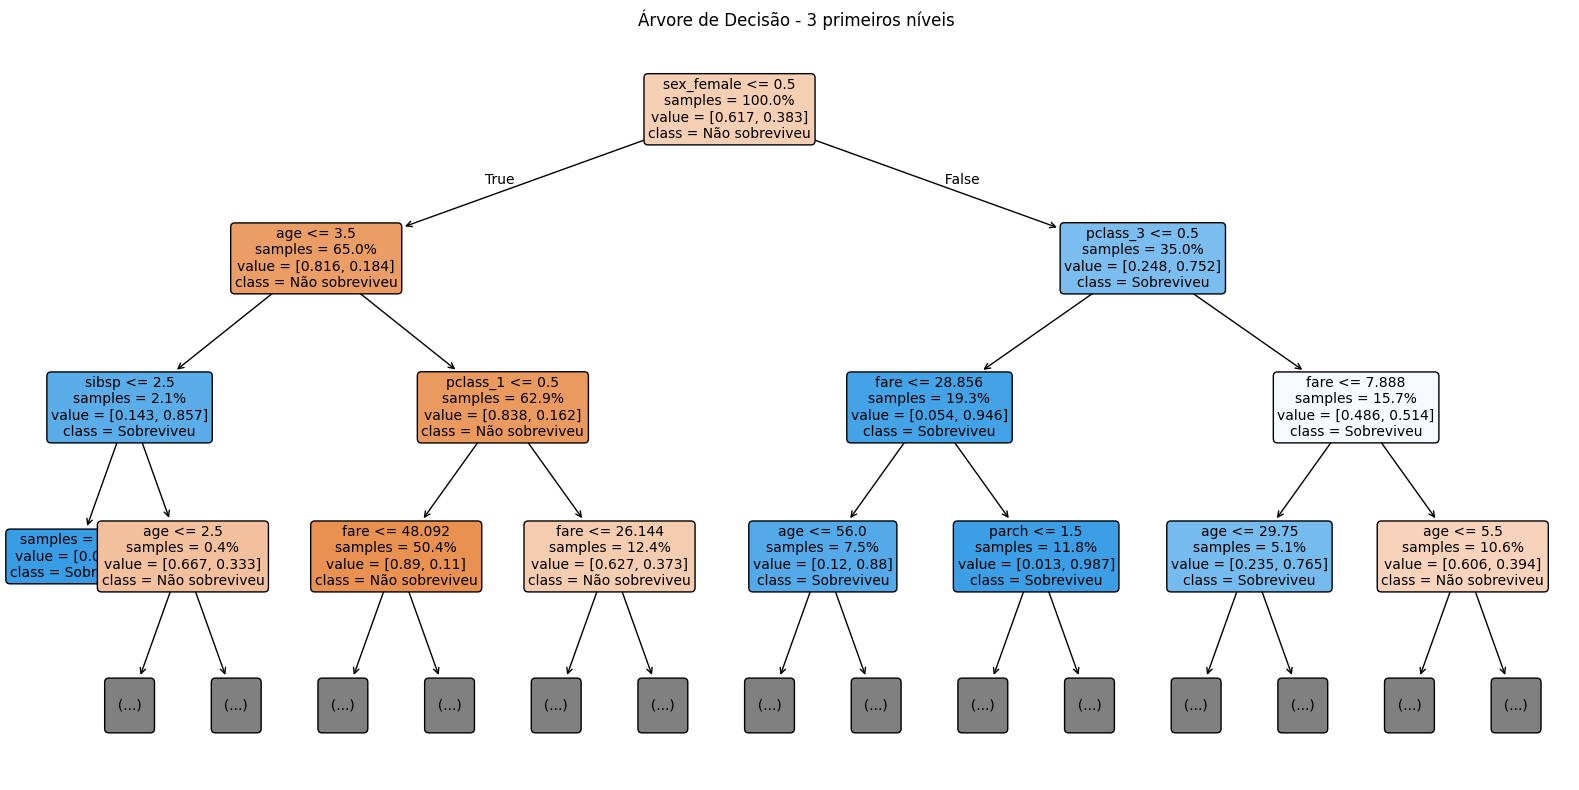

In [20]:
# Desenhar apenas os primeiros níveis da árvore (visualização didática)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Nomes das features após o pré-processamento (numéricas + one-hot das categóricas)
ohe = tree_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = num_features + list(ohe.get_feature_names_out(cat_features))

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree_model.named_steps['classifier'],
    feature_names=feature_names,
    class_names=["Não sobreviveu", "Sobreviveu"],
    max_depth=3,        # mostra apenas os 3 primeiros níveis
    filled=True,
    rounded=True,
    proportion=True,    # proporções no lugar de contagens (menos texto no nó)
    impurity=False,     # esconde o gini
    fontsize=10,
    ax=ax
)
ax.set_title("Árvore de Decisão - 3 primeiros níveis")
plt.tight_layout()
plt.show()   # evita a impressão da lista de objetos Text(...)

### Árvore podada de verdade

Acima cortamos só a visualização. Aqui treinamos um modelo *de fato* pequeno, com
`max_depth=3` e `min_samples_leaf=20`. Além de ser fácil de ler, ele costuma
generalizar melhor do que a árvore sem limite de profundidade.

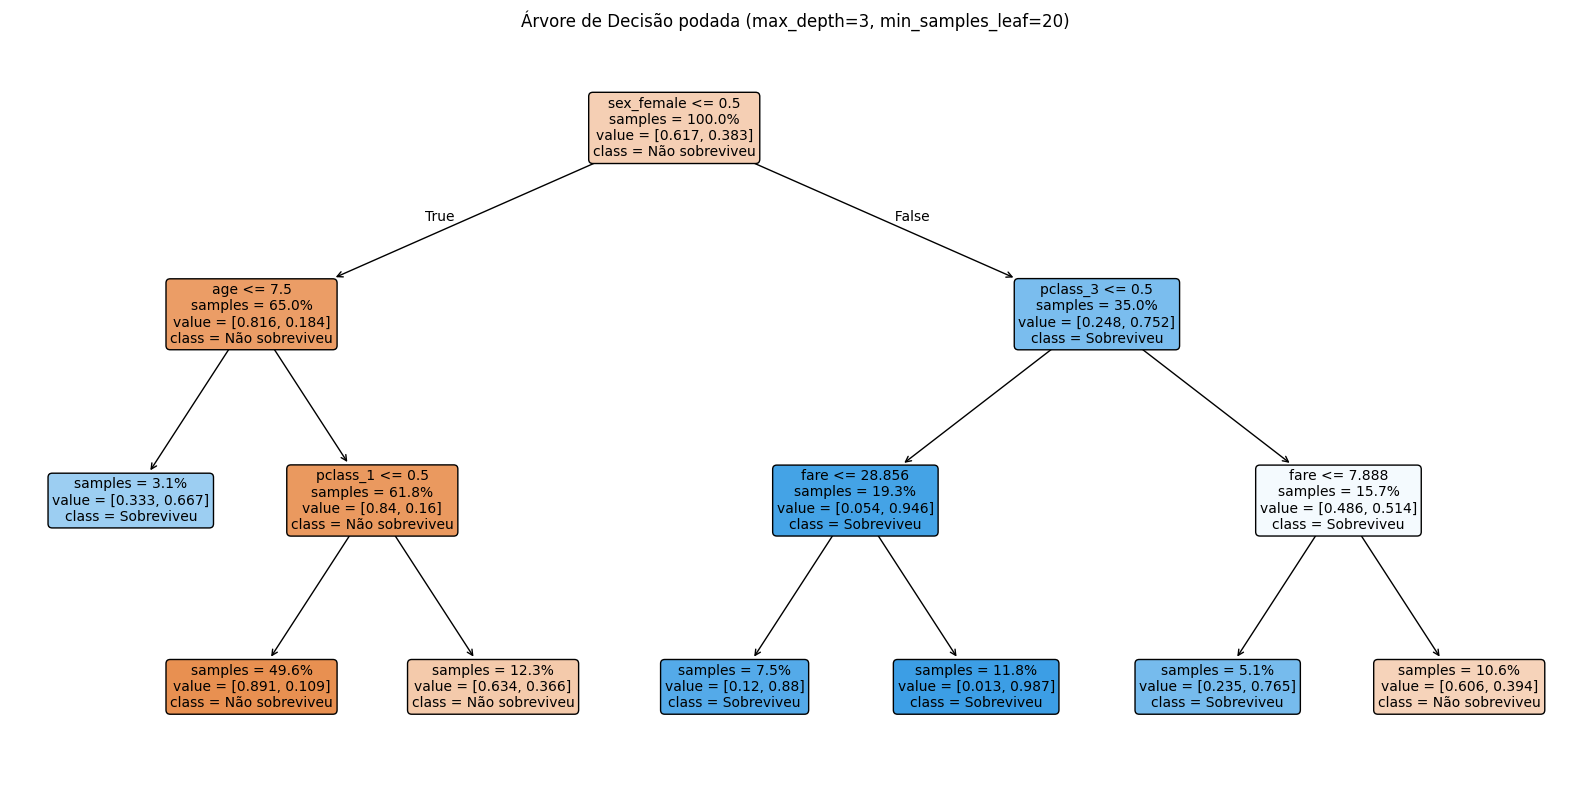

Acurácia (árvore podada): 0.776


In [21]:
# Versão didática: árvore realmente pequena (e não apenas cortada no desenho)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_simples = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("classifier", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42))
])
tree_simples.fit(X_train, y_train)

# Nomes das features após o pré-processamento (recalculados aqui para a célula ser independente)
ohe = tree_simples.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = num_features + list(ohe.get_feature_names_out(cat_features))

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree_simples.named_steps['classifier'],
    feature_names=feature_names,
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=False,
    fontsize=10,
    ax=ax
)
ax.set_title("Árvore de Decisão podada (max_depth=3, min_samples_leaf=20)")
plt.tight_layout()
plt.show()

print("Acurácia (árvore podada):", round(tree_simples.score(X_test, y_test), 3))

## ✅ Análise Comparativa

### 📊 Resultados

| Métrica            | Regressão Logística | Árvore de Decisão |
|--------------------|---------------------|--------------------|
| Acurácia           | 0.79                | 0.72               |
| F1-score (Classe 0)| 0.83                | 0.77               |
| F1-score (Classe 1)| 0.71                | 0.65               |

---

### 🧠 Interpretação

#### 🔹 1. Regressão Logística teve melhor desempenho
A **Regressão Logística** apresentou maior acurácia e F1-score, mostrando melhor **capacidade de generalização**.  
O modelo manteve bom equilíbrio entre **precisão** e **recall**, especialmente na classe dos sobreviventes.

---

#### 🔹 2. Por que a Árvore de Decisão foi pior?
Apesar de ser flexível e capaz de aprender padrões complexos, a **Árvore de Decisão** é muito sensível ao conjunto de treinamento.  
Ela tende a **memorizar ruídos e detalhes específicos** (overfitting), perdendo desempenho nos dados de teste.

> Em datasets pequenos como o *Titanic*, isso é ainda mais evidente — a árvore aprende demais o treino e erra mais no teste.

---

#### 🔹 3. Por que a Regressão Logística funciona melhor aqui?
O problema do *Titanic* possui relações **simples e quase lineares**:
- Passageiros **mulheres**, de **classe alta** e **idade baixa** tinham maior chance de sobreviver.
- Cada variável contribui de forma **aditiva** e previsível.

Como a **Regressão Logística é um modelo linear e paramétrico**, ela se ajusta muito bem a esse tipo de relação.

---

#### 🔹 4. Quando a Árvore pode superar?
A Árvore de Decisão se destaca quando:
- há **relações não lineares complexas** entre variáveis,
- o dataset contém **muitos atributos categóricos**,
- ou há **interações sutis** entre variáveis que um modelo linear não captura.

Mas como o *Titanic* é um problema de estrutura simples, a Regressão Logística acaba sendo mais adequada.

---

### 💬 **Conclusão**
> A Regressão Logística teve desempenho superior por capturar bem as relações lineares entre as variáveis do Titanic.  
> Já a Árvore de Decisão, embora mais flexível, acabou se ajustando demais ao conjunto de treino, o que reduziu sua precisão nos dados de teste.
